# Career Planning Dashboard — Analytical Notebook

**ACC102 Mini Assignment | Track 4: Interactive Data Analysis Tool**

## 1. Problem Definition & User

**Analytical Problem:** Job seekers and university students often lack a clear, data-driven understanding of how factors like education level, years of experience, and job category affect salary outcomes. This project builds an interactive dashboard that helps users explore salary trends, identify in-demand roles, and discover which skills are most valuable in the job market.

**Target User:** Final-year university students and early-career professionals making career decisions.

**Data Source:** `Salary_Data.csv` from Kaggle (https://www.kaggle.com/), accessed April 2026. The dataset contains 6,704 records with 6 fields: Age, Gender, Education Level, Job Title, Years of Experience, and Salary.

## 2. Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Load raw data
df_raw = pd.read_excel("Salary_Data.xlsx")
print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn types:\n{df_raw.dtypes}")
df_raw.head(10)

Dataset shape: (6704, 6)

Column types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


## 3. Data Cleaning & Preparation

Several issues need to be addressed before analysis:
1. **Missing values** — a small number of rows have null values
2. **Inconsistent education labels** — e.g. "Bachelor's" vs "Bachelor's Degree", "PhD" vs "phD"
3. **Salary outliers** — some values below $10,000 appear to be data entry errors

In [4]:
# 3.1 Check missing values
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal rows with any null: {df_raw.isnull().any(axis=1).sum()}")

Missing values per column:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

Total rows with any null: 6


In [5]:
# 3.2 Drop rows with missing values (only ~5 rows, safe to remove)
df = df_raw.dropna().copy()
print(f"Rows after dropping nulls: {len(df)} (removed {len(df_raw) - len(df)})")

Rows after dropping nulls: 6698 (removed 6)


In [17]:
# 3.3 Standardise Education Level labels
print("Before cleaning:")
print(df["Education Level"].value_counts())

edu_map = {
    "Bachelor's": "Bachelor's",
    "Bachelor's Degree": "Bachelor's",
    "Master's": "Master's",
    "Master's Degree": "Master's",
    "PhD": "PhD",
    "phD": "PhD",
    "High School": "High School"
}
df["Education Level"] = df["Education Level"].map(edu_map)
df = df.dropna(subset=["Education Level"])

print("\nAfter cleaning:")
print(df["Education Level"].value_counts())

Before cleaning:
Education Level
Bachelor's     3018
Master's       1860
PhD            1368
High School     448
Name: count, dtype: int64

After cleaning:
Education Level
Bachelor's     3018
Master's       1860
PhD            1368
High School     448
Name: count, dtype: int64


In [7]:
# 3.4 Remove salary outliers
print(f"Salary range before: ${df['Salary'].min():,.0f} – ${df['Salary'].max():,.0f}")
print(f"Records with salary < $10,000: {(df['Salary'] < 10000).sum()}")

df = df[df["Salary"] >= 10000]
print(f"\nSalary range after: ${df['Salary'].min():,.0f} – ${df['Salary'].max():,.0f}")
print(f"Final dataset size: {len(df)} rows")

Salary range before: $350 – $250,000
Records with salary < $10,000: 4

Salary range after: $25,000 – $250,000
Final dataset size: 6694 rows


## 4. Feature Engineering

To make the dashboard more useful, we create two new features:
- **Job Category**: Groups 193 individual job titles into broader career categories (e.g. "Software Engineering", "Data & Analytics", "Marketing")
- **Experience Level**: Bins years of experience into entry/junior/mid/senior levels

In [8]:
# 4.1 Create Job Category from Job Title keywords
def categorise_job(title):
    """Map job title to a broader career category using keyword matching."""
    t = title.lower()
    if any(w in t for w in ["software", "developer", "engineer", "full stack", "front end", "back end"]):
        return "Software Engineering"
    elif any(w in t for w in ["data scientist", "data analyst", "data engineer", "business intelligence"]):
        return "Data & Analytics"
    elif any(w in t for w in ["marketing", "content", "social media", "seo"]):
        return "Marketing"
    elif any(w in t for w in ["financial", "accountant", "finance"]):
        return "Finance & Accounting"
    elif any(w in t for w in ["product manager", "project manager", "project engineer"]):
        return "Product & Project Mgmt"
    elif any(w in t for w in ["sales", "business develop", "account manager"]):
        return "Sales & Business Dev"
    elif any(w in t for w in ["human resource", "hr ", "recruiter", "talent"]):
        return "Human Resources"
    elif any(w in t for w in ["operations", "supply chain", "logistics"]):
        return "Operations"
    elif any(w in t for w in ["director", "ceo", "cto", "cfo", "vp ", "vice president", "chief"]):
        return "Executive / Leadership"
    elif any(w in t for w in ["manager", "senior"]):
        return "Management"
    else:
        return "Other"

df["Job Category"] = df["Job Title"].apply(categorise_job)
print("Job Category distribution:")
print(df["Job Category"].value_counts())

Job Category distribution:
Job Category
Software Engineering      2659
Marketing                 1019
Data & Analytics           907
Sales & Business Dev       470
Product & Project Mgmt     358
Human Resources            354
Other                      269
Executive / Leadership     208
Finance & Accounting       206
Operations                 151
Management                  93
Name: count, dtype: int64


In [9]:
# 4.2 Create Experience Level bins
df["Experience Level"] = pd.cut(
    df["Years of Experience"],
    bins=[0, 2, 5, 10, 50],
    labels=["Entry (0-2yr)", "Junior (3-5yr)", "Mid (6-10yr)", "Senior (10+yr)"]
)
print("Experience Level distribution:")
print(df["Experience Level"].value_counts().sort_index())

Experience Level distribution:
Experience Level
Entry (0-2yr)     1160
Junior (3-5yr)    1522
Mid (6-10yr)      1787
Senior (10+yr)    2105
Name: count, dtype: int64


## 5. Exploratory Analysis

### 5.1 Which Roles Are Most Common?

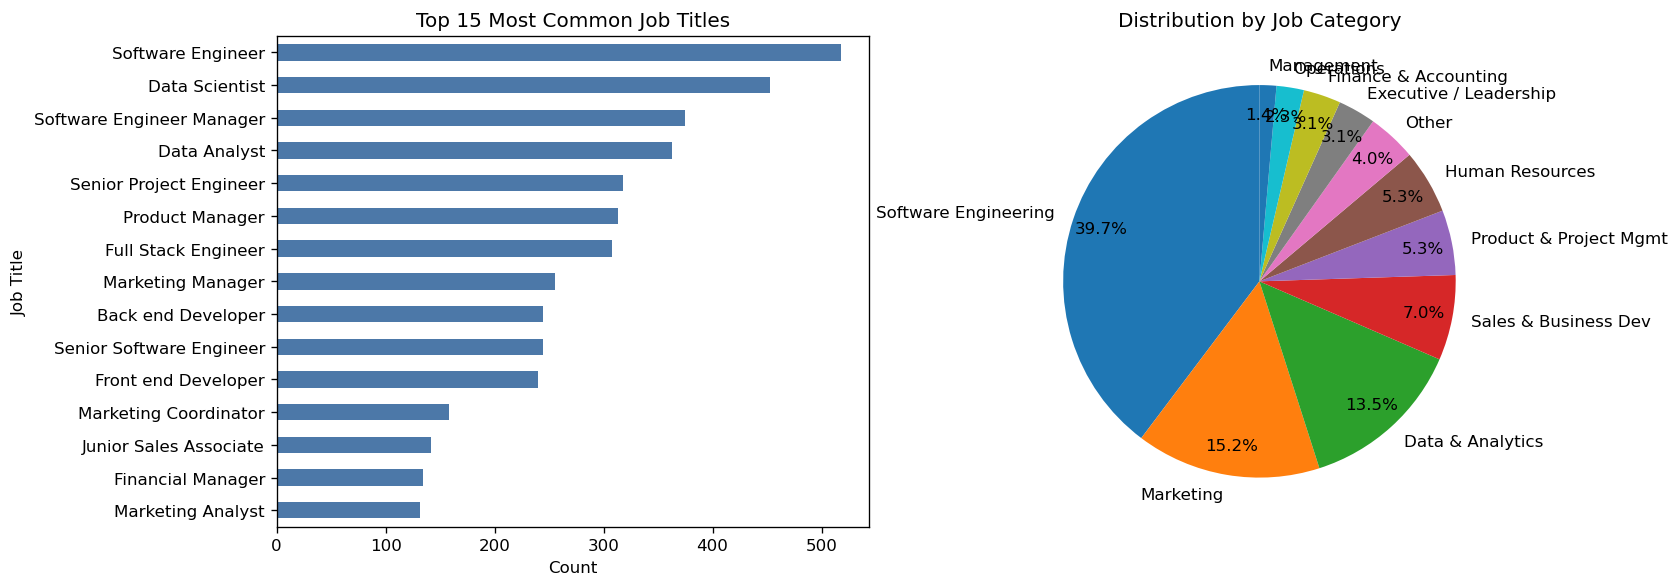


Key finding: Software Engineering and Marketing are the two largest categories.


In [14]:
# Top 15 most common job titles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top jobs
top15 = df["Job Title"].value_counts().head(15)
top15.plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 Most Common Job Titles")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# Pie chart of job categories
cat_counts = df["Job Category"].value_counts()
cat_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90, pctdistance=0.85)
axes[1].set_title("Distribution by Job Category")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("fig1_job_distribution.png", bbox_inches="tight")
plt.show()
print("\nKey finding: Software Engineering and Marketing are the two largest categories.")

### 5.2 How Does Salary Vary by Education and Experience?

/var/folders/sj/xgh5tlt57wnbycw8t_5kbs780000gn/T/ipykernel_15894/1581792565.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(edu_data, labels=edu_order, patch_artist=True)


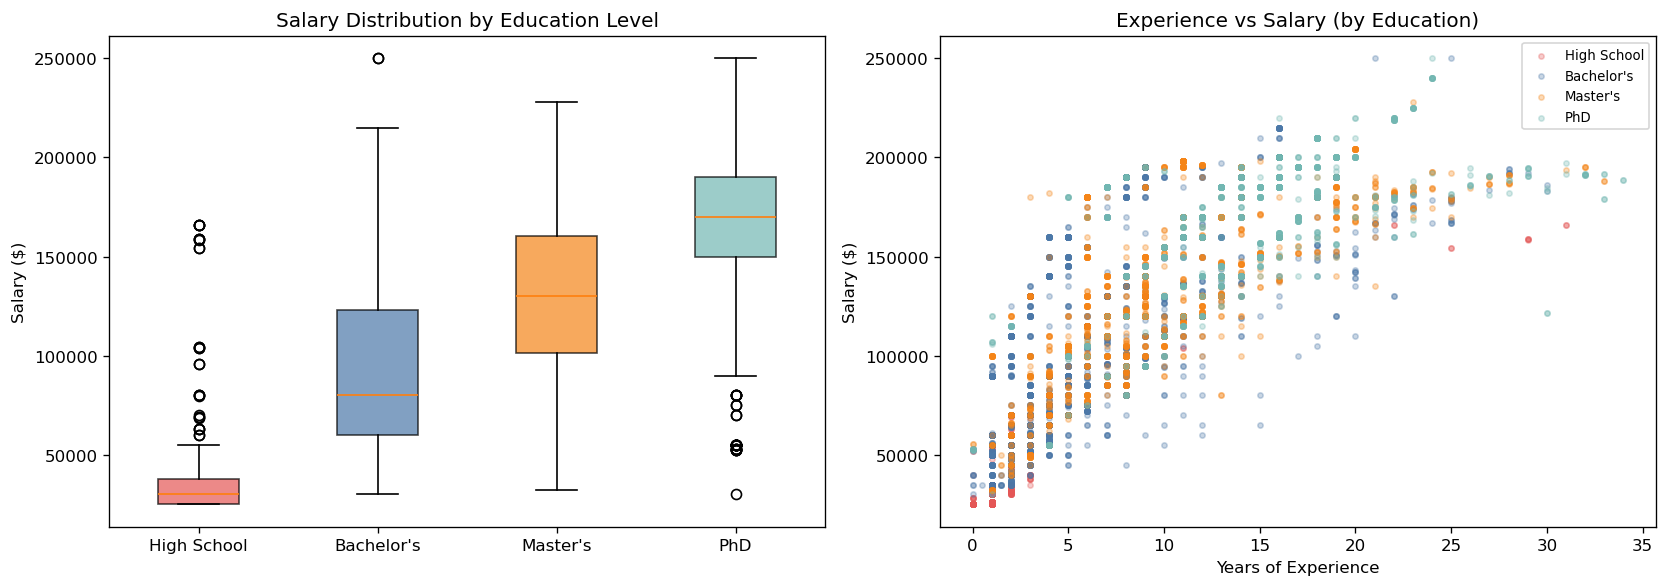

Median salary by education level:
  High School    : $    30,000
  Bachelor's     : $    80,000
  Master's       : $   130,000
  PhD            : $   170,000


In [16]:
# Salary distribution by education level
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: salary by education
edu_data = [df[df["Education Level"] == e]["Salary"] for e in edu_order]
bp = axes[0].boxplot(edu_data, labels=edu_order, patch_artist=True)
colors = ["#E45756", "#4C78A8", "#F58518", "#72B7B2"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Salary Distribution by Education Level")
axes[0].set_ylabel("Salary ($)")

# Scatter plot: experience vs salary coloured by education
for i, edu in enumerate(edu_order):
    subset = df[df["Education Level"] == edu]
    axes[1].scatter(subset["Years of Experience"], subset["Salary"],
                    alpha=0.3, label=edu, s=10, color=colors[i])
axes[1].set_title("Experience vs Salary (by Education)")
axes[1].set_xlabel("Years of Experience")
axes[1].set_ylabel("Salary ($)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig2_salary_education.png", bbox_inches="tight")
plt.show()

# Summary statistics
print("Median salary by education level:")
for edu in edu_order:
    median_sal = df[df["Education Level"] == edu]["Salary"].median()
    print(f"  {edu:15s}: ${median_sal:>10,.0f}")

### 5.3 Salary by Job Category

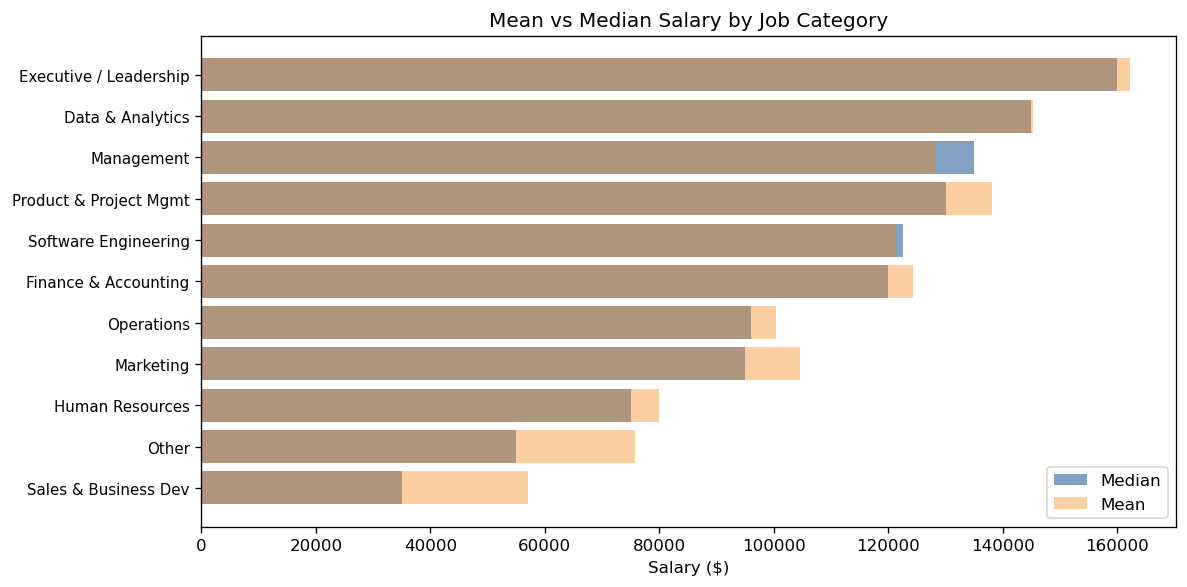


Salary summary by category:
                          Mean Salary  Median Salary  Count
Job Category                                               
Sales & Business Dev     57044.680851        35000.0    470
Other                    75817.843866        55000.0    269
Human Resources          79983.050847        75000.0    354
Marketing               104530.912659        95000.0   1019
Operations              100377.483444        96000.0    151
Finance & Accounting    124223.300971       120000.0    206
Software Engineering    121416.456563       122485.0   2659
Product & Project Mgmt  138100.558659       130000.0    358
Management              128225.806452       135000.0     93
Data & Analytics        145262.403528       145000.0    907
Executive / Leadership  162139.423077       160000.0    208


In [18]:
# Average and median salary by job category
cat_salary = df.groupby("Job Category")["Salary"].agg(["mean", "median", "count"])
cat_salary.columns = ["Mean Salary", "Median Salary", "Count"]
cat_salary = cat_salary.sort_values("Median Salary", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(cat_salary))
ax.barh(y_pos, cat_salary["Median Salary"], color="#4C78A8", alpha=0.7, label="Median")
ax.barh(y_pos, cat_salary["Mean Salary"], color="#F58518", alpha=0.4, label="Mean")
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_salary.index, fontsize=9)
ax.set_xlabel("Salary ($)")
ax.set_title("Mean vs Median Salary by Job Category")
ax.legend()

plt.tight_layout()
plt.savefig("fig3_salary_by_category.png", bbox_inches="tight")
plt.show()

print("\nSalary summary by category:")
print(cat_salary.to_string())

### 5.4 Salary Heatmap: Education × Experience Level

/var/folders/sj/xgh5tlt57wnbycw8t_5kbs780000gn/T/ipykernel_15894/597695740.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(["Education Level", "Experience Level"])["Salary"].mean().reset_index()


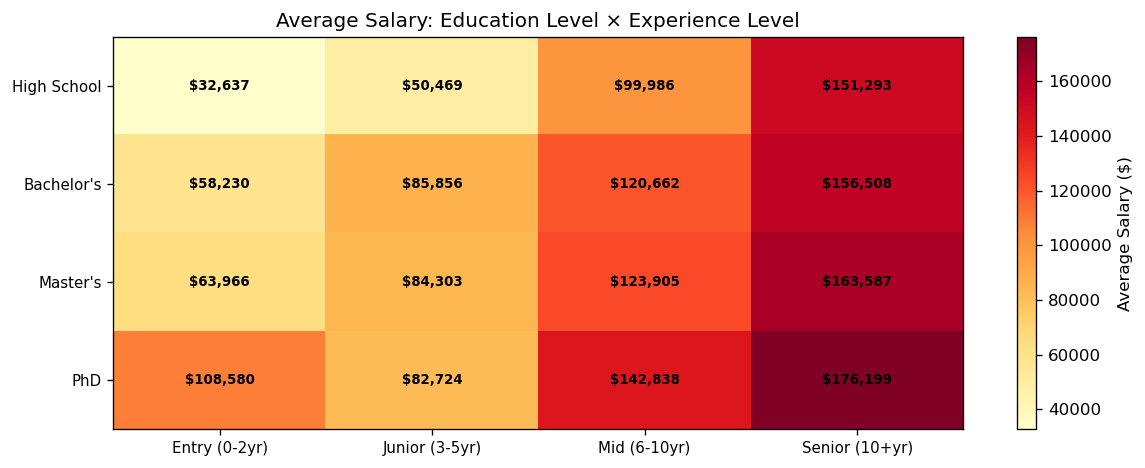


Key finding: The salary premium for higher education is most visible at senior experience levels.


In [19]:
# Heatmap of average salary by education and experience level
heatmap_data = df.groupby(["Education Level", "Experience Level"])["Salary"].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index="Education Level", columns="Experience Level", values="Salary")
heatmap_pivot = heatmap_pivot.reindex(edu_order)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_pivot.values, cmap="YlOrRd", aspect="auto")

# Labels
ax.set_xticks(range(len(heatmap_pivot.columns)))
ax.set_xticklabels(heatmap_pivot.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index, fontsize=9)

# Add value annotations
for i in range(len(heatmap_pivot.index)):
    for j in range(len(heatmap_pivot.columns)):
        val = heatmap_pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"${val:,.0f}", ha="center", va="center", fontsize=8, fontweight="bold")

plt.colorbar(im, ax=ax, label="Average Salary ($)")
ax.set_title("Average Salary: Education Level × Experience Level")

plt.tight_layout()
plt.savefig("fig4_salary_heatmap.png", bbox_inches="tight")
plt.show()

print("\nKey finding: The salary premium for higher education is most visible at senior experience levels.")

### 5.5 Skills Analysis

Since the original dataset does not contain a skills column, we enrich the data by mapping each job title to commonly required skills based on industry knowledge. This allows us to answer the question: **which skills are most in-demand and which correlate with higher salaries?**

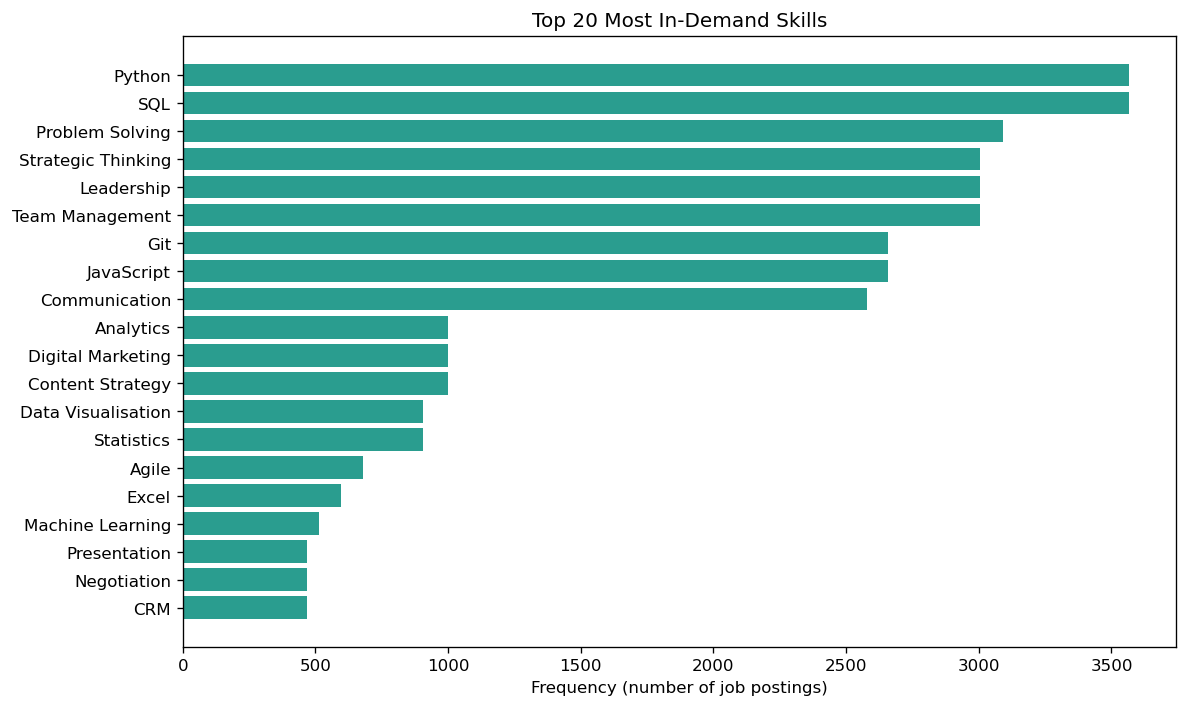

In [20]:
from collections import Counter

def map_skills(title):
    """Map job titles to commonly required skills based on industry knowledge."""
    t = title.lower()
    skills = []
    if any(w in t for w in ["software", "developer", "full stack", "front end", "back end", "engineer"]):
        skills.extend(["Python", "JavaScript", "Git", "SQL", "Problem Solving"])
    if "front end" in t:
        skills.extend(["HTML/CSS", "React", "UI Design"])
    if "back end" in t:
        skills.extend(["API Design", "Database", "Cloud"])
    if "data scientist" in t:
        skills.extend(["Python", "Machine Learning", "Statistics", "SQL", "Data Visualisation"])
    if "data analyst" in t:
        skills.extend(["SQL", "Excel", "Python", "Data Visualisation", "Statistics"])
    if any(w in t for w in ["marketing"]):
        skills.extend(["Digital Marketing", "Analytics", "Communication", "Content Strategy"])
    if any(w in t for w in ["financial", "accountant", "finance"]):
        skills.extend(["Excel", "Financial Analysis", "Accounting", "ERP Systems"])
    if any(w in t for w in ["product manager"]):
        skills.extend(["Product Strategy", "Agile", "Communication", "Data Analysis", "UX"])
    if any(w in t for w in ["project manager", "project engineer"]):
        skills.extend(["Project Planning", "Agile", "Communication", "Risk Management"])
    if any(w in t for w in ["sales", "business develop"]):
        skills.extend(["Negotiation", "CRM", "Communication", "Presentation"])
    if any(w in t for w in ["manager", "director", "senior", "lead", "chief", "vp "]):
        skills.extend(["Leadership", "Strategic Thinking", "Team Management"])
    if not skills:
        skills.extend(["Communication", "Problem Solving", "Teamwork"])
    return list(set(skills))

df["Skills"] = df["Job Title"].apply(map_skills)

# Count all skills
all_skills = []
for s_list in df["Skills"]:
    all_skills.extend(s_list)

skill_counts = Counter(all_skills)
top20 = pd.DataFrame(skill_counts.most_common(20), columns=["Skill", "Frequency"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20["Skill"], top20["Frequency"], color="#2A9D8F")
ax.invert_yaxis()
ax.set_title("Top 20 Most In-Demand Skills")
ax.set_xlabel("Frequency (number of job postings)")
plt.tight_layout()
plt.savefig("fig5_top_skills.png", bbox_inches="tight")
plt.show()

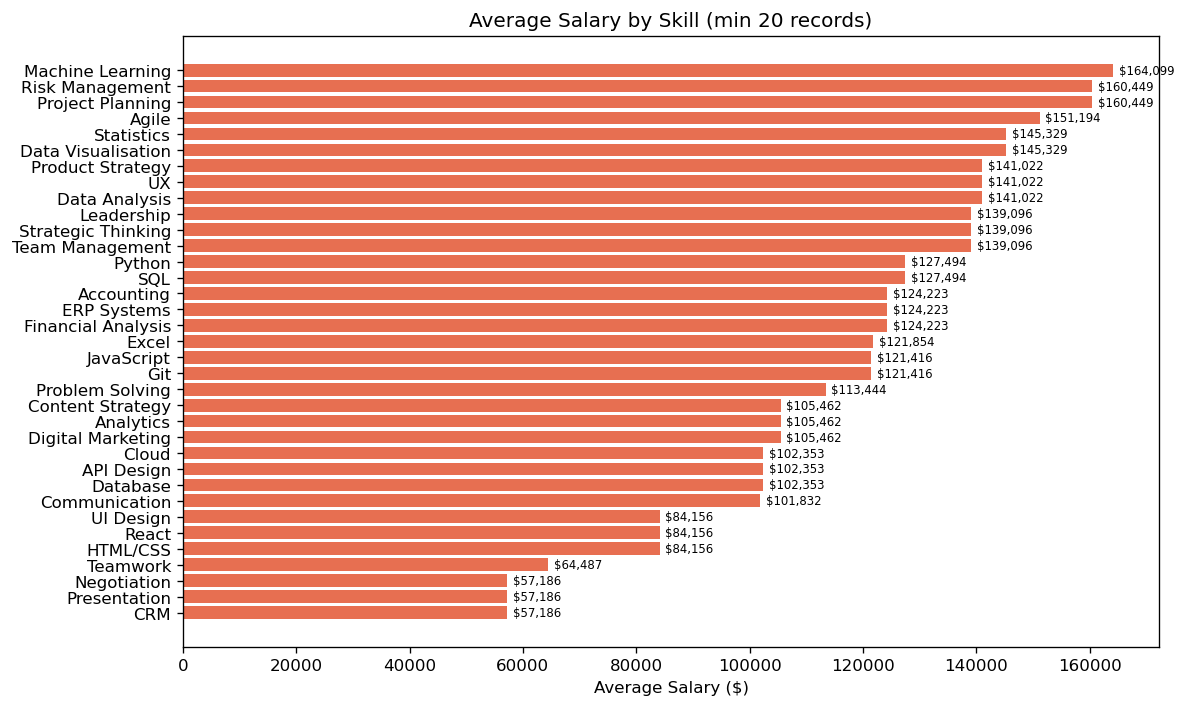


Key finding: Technical skills like Cloud, API Design, and Machine Learning
are associated with the highest average salaries.


In [21]:
# Average salary per skill
skill_salary = {}
for _, row in df.iterrows():
    for skill in row["Skills"]:
        if skill not in skill_salary:
            skill_salary[skill] = []
        skill_salary[skill].append(row["Salary"])

skill_sal_df = pd.DataFrame([
    {"Skill": skill, "Avg Salary": sum(sals)/len(sals), "Count": len(sals)}
    for skill, sals in skill_salary.items()
    if len(sals) >= 20
]).sort_values("Avg Salary", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(skill_sal_df["Skill"], skill_sal_df["Avg Salary"], color="#E76F51")
ax.set_title("Average Salary by Skill (min 20 records)")
ax.set_xlabel("Average Salary ($)")
# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1000, bar.get_y() + bar.get_height()/2,
            f"${width:,.0f}", ha="left", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("fig6_skill_salary.png", bbox_inches="tight")
plt.show()

print("\nKey finding: Technical skills like Cloud, API Design, and Machine Learning")
print("are associated with the highest average salaries.")

## 6. Key Findings Summary

1. **Software Engineering and Data & Analytics** are the two most common job categories, together representing the largest share of postings.
2. **Higher education correlates with higher salary**, but the gap is most pronounced at senior experience levels. A PhD holder with 10+ years earns significantly more than a Bachelor's holder at the same level.
3. **Experience is the strongest salary predictor** — the scatter plot shows a clear positive trend regardless of education level.
4. **Executive and Management roles** command the highest median salaries, while Sales and HR tend to be lower.
5. **Technical skills** (Python, SQL, Cloud, Machine Learning) are associated with above-average salaries, while soft skills alone (Communication, Teamwork) correlate with lower pay.

These findings are presented interactively in the Streamlit dashboard, where users can filter by education, experience, and job category to explore personalised insights.